# Sesión 15: Interpretando Modelos "Caja Negra" con SHAP y LIME

**Objetivos:**
-   Entender la diferencia entre interpretabilidad **Global** y **Local**.
-   Utilizar `feature_importance_` para explicaciones globales en modelos de árboles.
-   Comprender la intuición detrás de LIME y SHAP para explicaciones locales.
-   Generar e interpretar los gráficos de SHAP para entender las predicciones de un modelo.

## 1. Global vs. Local: Las Dos Caras de la Interpretabilidad

No todas las explicaciones responden a la misma pregunta.

* **Interpretabilidad Global:** Busca entender el comportamiento **general** del modelo.
    * **Pregunta Clave:** ¿Qué características son las más importantes para el modelo en su conjunto?
    * **Analogía:** ¿Qué factores considera un banco, en general, para decidir si aprueba un préstamo? (Ej: ingresos, historial crediticio, deudas).

* **Interpretabilidad Local:** Busca entender una **única predicción**.
    * **Pregunta Clave:** ¿Por qué a *este cliente en particular* se le ha denegado el préstamo?
    * **Analogía:** Se te ha denegado el préstamo porque, aunque tus ingresos son altos, tu ratio de deuda es demasiado elevado para *tu caso específico*.

## 2. Lo Básico: Feature Importance (Global)

Ya la conocemos de los modelos de árboles como Random Forest. `feature_importance_` nos da una puntuación para cada característica, indicando cuánto ha contribuido a reducir la impureza en los nodos del árbol.

* **Ventaja:** Rápido y fácil de obtener.
* **Desventaja:** Nos dice **qué** es importante, pero no **cómo** afecta. (Ej: sabemos que la "antigüedad" del cliente es importante para predecir el churn, pero ¿los clientes antiguos se van más o menos?).

## 3. El Estándar de Oro: SHAP (SHapley Additive exPlanations)

SHAP es la técnica más moderna y robusta. Se basa en la teoría de juegos para asignar a cada característica la "culpa" o el "mérito" que le corresponde en una predicción.

* **Intuición:** Imagina que una predicción es el "premio" de un juego. SHAP calcula cómo repartir ese premio de forma justa entre las características ("jugadores") según la contribución de cada una.
* **Superpotencia:** Ofrece tanto explicaciones **locales** consistentes como gráficos **globales** increíblemente informativos.

### Gráficos Clave de SHAP:
* **Force Plot (Explicación Local):** Muestra una "lucha" de fuerzas. Las características en **rojo** empujan la predicción hacia un valor más alto (ej. "Churn"), y las de **azul** la empujan hacia un valor más bajo (ej. "No Churn").
* **Summary Plot (Explicación Global):** Agrega las explicaciones de muchos puntos. Nos muestra las características más importantes y, además, si valores altos o bajos de esa característica afectan positiva o negativamente a la predicción. **Responde a la pregunta que `feature_importance_` no podía.**

---
## 🛠️ Exploración Aplicada: ¿Por Qué se Van Nuestros Clientes?

Vamos a usar el modelo `RandomForestClassifier` sobre el dataset de **Telco Customer Churn**. Nuestro objetivo es usar SHAP para entender por qué predice lo que predice.

**Instalación (si no lo tienes):**
`pip install shap`

### Actividad 1: Análisis Local
1.  **Carga el modelo y los datos** .
2.  **Crea un `shap.Explainer`** para el modelo Random Forest.
3.  Calcula los **valores SHAP** para el conjunto de test.
4.  Elige **un cliente que el modelo predijo que se iría (`Churn=1`)** y **otro que predijo que se quedaría (`Churn=0`)**.
5.  Para cada uno de ellos, genera e interpreta su **gráfico de fuerza (force plot)**. ¿Qué factores específicos influyeron en cada decisión?

### Actividad 2: Análisis Global
1.  Usando los mismos valores SHAP, genera el **`summary_plot`**.
2.  **Responde a las siguientes preguntas de reflexión**:
    * Compara el `summary_plot` de SHAP con el `feature_importance_` del Random Forest. ¿Qué nueva información te da SHAP que la otra no te daba? (Pista: mira los colores).
    * Observando el `force plot` del cliente que iba a hacer "Churn", si fueras el jefe del equipo de retención, ¿qué **acción personalizada y específica** podrías ofrecerle a *ese cliente* para intentar que se quede?
    * Explica con tus propias palabras la diferencia entre una explicación **global** y una **local** en el contexto de este problema de negocio.

In [2]:
# Importación de librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# Cargar el dataset
# Asegúrate de que el archivo .csv esté en la misma carpeta o ajusta la ruta
df = pd.read_csv('./WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Vista preliminar de los datos
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Limpieza Inicial de Datos

El primer paso es eliminar aquellas variables que no aportan información predictiva.
La columna `customerID` es un identificador único aleatorio. Mantenerla podría generar ruido en el modelo, ya que este podría intentar aprender patrones basados en el ID en lugar de las características reales del cliente.

In [3]:
# Eliminamos la columna ID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
    print("Columna 'customerID' eliminada correctamente.")
else:
    print("La columna 'customerID' ya no existe en el dataframe.")

# Verificamos tipos de datos preliminares
df.info()

Columna 'customerID' eliminada correctamente.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 

## 3. Limpieza de Datos y Consistencia

En este paso abordaremos dos problemas de calidad de datos detectados:

1.  **Errores en `TotalCharges`:** Esta variable numérica contiene espacios en blanco (`" "`) que impiden su cálculo. Los convertiremos a `NaN` y asumiremos que son 0 (clientes nuevos).
2.  **Redundancia en Categorías:** Varias columnas (`OnlineSecurity`, `TechSupport`, etc.) tienen la categoría *"No internet service"*.
    * Desde el punto de vista lógico, si no tienen internet, no tienen el servicio.
    * Para simplificar el modelo y reducir la dimensionalidad, reemplazaremos *"No internet service"* y *"No phone service"* simplemente por **"No"**.

**Columnas afectadas por redundancia:**
* `MultipleLines` (Contiene "No phone service")
* `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` (Contienen "No internet service")

In [4]:
# 1. Convertir a numérico (errores se vuelven NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Rellenar nulos con 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Corrección de 'TotalCharges' completada.")

# --- B. ESTANDARIZACIÓN DE CATEGORÍAS ---

# Definimos las columnas que queremos limpiar para verificar el antes y después
cols_redundantes = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

print("\n--- Antes del reemplazo (Valores únicos) ---")
for col in cols_redundantes:
    print(f"{col}: {df[col].unique()}")

# Reemplazamos los valores redundantes por "No" en todo el DataFrame
df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)

print("\n--- Después del reemplazo (Valores únicos) ---")
for col in cols_redundantes:
    print(f"{col}: {df[col].unique()}")

Corrección de 'TotalCharges' completada.

--- Antes del reemplazo (Valores únicos) ---
MultipleLines: ['No phone service' 'No' 'Yes']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']


TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']

--- Después del reemplazo (Valores únicos) ---
MultipleLines: ['No' 'Yes']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']


## 5. Codificación de Variables Binarias (Booleanas)

Para mantener la consistencia y mejorar la legibilidad semántica, convertiremos las variables que tienen solo dos estados posibles a tipo **Booleano** (`True` / `False`).

Variables afectadas:
1.  **`Churn` (Target):** De "Yes"/"No" a `True`/`False`.
2.  **`SeniorCitizen`:** De 1/0 a `True`/`False`.
3.  **`Has_Family`:** De 1/0 a `True`/`False`.

Esto alineará estas columnas con el formato que generaremos posteriormente para las variables categóricas.

Tipos de datos actualizados:
Churn            bool
SeniorCitizen    bool
dtype: object

Distribución de la variable Churn:
Churn
False    0.73463
True     0.26537
Name: proportion, dtype: float64


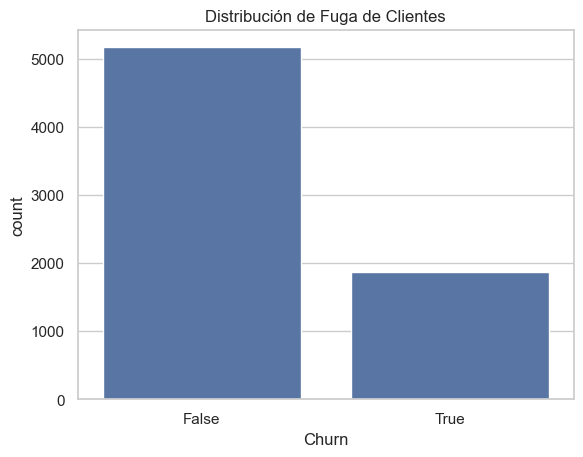

In [5]:
# 1. Mapeo de la variable objetivo (Target) directamente a Booleano
df['Churn'] = df['Churn'].map({'Yes': True, 'No': False})

# 2. Conversión de otras binarias numéricas a Booleanas
cols_to_bool = ['SeniorCitizen', 'Has_Family']

# Convertimos asegurándonos de que existan en el df
for col in cols_to_bool:
    if col in df.columns:
        df[col] = df[col].astype(bool)

# Verificamos los tipos de datos y el balance
print("Tipos de datos actualizados:")
print(df[['Churn', 'SeniorCitizen']].dtypes)

print("\nDistribución de la variable Churn:")
print(df['Churn'].value_counts(normalize=True))

# Visualización
sns.countplot(x='Churn', data=df)
plt.title('Distribución de Fuga de Clientes')
plt.show()

## 6. Ingeniería de Características: One-Hot Encoding

Tenemos muchas variables categóricas (Género, Tipo de contrato, Método de pago, etc.). Para que modelos matemáticos como SVM, Regresión Logística o Redes Neuronales puedan interpretarlas, debemos convertirlas a números.



Utilizaremos **One-Hot Encoding** (creación de variables dummy).
* *Nota:* Usaremos `drop_first=True` para evitar la multicolinealidad (la "trampa de las variables dummy"), lo cual es especialmente importante para la Regresión Logística.

In [6]:
# Identificamos las columnas categóricas (excluyendo la target numérica 'Churn')
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Variables categóricas a codificar: {list(categorical_cols)}")

# Aplicamos One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Dimensiones del dataset tras el encoding: {df_encoded.shape}")
df_encoded.head()

Variables categóricas a codificar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Dimensiones del dataset tras el encoding: (7043, 24)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,False,1,29.85,29.85,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False
1,False,34,56.95,1889.50,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True
2,False,2,53.85,108.15,True,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,True,False,False,True
3,False,45,42.30,1840.75,False,True,False,False,False,False,False,False,True,False,True,True,False,False,True,False,False,False,False,False
4,False,2,70.70,151.65,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False


## 7. División (Train-Test Split) y Escalado de Datos

Este paso es crítico.

1.  **División:** Separamos los datos en entrenamiento (80%) y prueba (20%) para poder evaluar nuestros modelos con datos desconocidos.
2.  **Escalado (StandardScaler):** Modelos como **KNN, SVM, Regresión Logística y Redes Neuronales** son sensibles a la magnitud de los datos. Variables como `TotalCharges` (miles) dominarían sobre `tenure` (decenas) si no las escalamos.

**Importante:** El escalado (`fit`) se realiza SOLO sobre el conjunto de entrenamiento (`X_train`) para evitar el **Data Leakage** (fuga de información del test al train). Luego, esa misma transformación se aplica al test.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definir X (features) e y (target)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 1. División Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

# 2. Escalado de variables
# Identificamos columnas numéricas que necesitan escalado
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# Ajustamos el scaler solo con X_train
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transformamos X_test con la media y desviación de X_train
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("\nPrimeras filas de X_train escalado:")
X_train.head()

Tamaño de X_train: (5634, 23)
Tamaño de X_test: (1409, 23)

Primeras filas de X_train escalado:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,False,0.102371,-0.521976,-0.262257,True,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,True,False
3151,False,-0.711743,0.337478,-0.503635,True,True,True,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True
4860,False,-0.793155,-0.809013,-0.749883,True,True,True,False,False,False,False,True,True,False,True,False,False,False,True,False,False,False,True
3867,False,-0.263980,0.284384,-0.172722,False,True,False,True,False,False,False,False,True,True,False,True,True,False,True,True,True,False,False
3810,False,-1.281624,-0.676279,-0.989374,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## 8. Regresión Logística
En esta sección entrenaremos un modelo de Regresión Logística para predecir la fuga de clientes (Churn).

Objetivos:
1. Ajustar el modelo usando los datos de entrenamiento (X_train, y_train).
2. Obtener predicciones sobre los datos de prueba (X_test) y las probabilidades de churn.
3. Evaluar el rendimiento del modelo usando métricas clásicas:
   - Classification Report (Precision, Recall, F1-score)
   - ROC-AUC (capacidad de distinguir entre churn y no churn)
   - Matriz de Confusión (visualización de aciertos y errores)
4. Interpretar los resultados y entender qué tan fiable es el modelo para detectar clientes que se van.



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       False       0.85      0.90      0.87      1035
        True       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8422


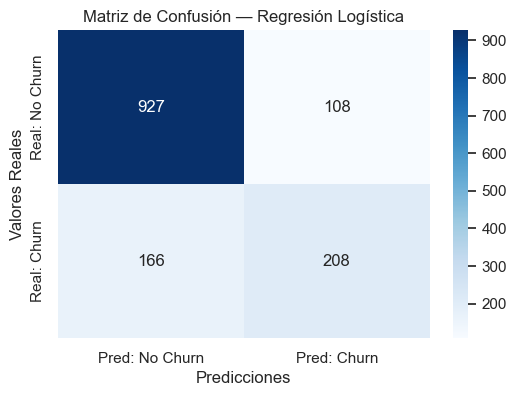

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Entrenamiento del modelo
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

# 2. Predicciones
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

# 3. Métricas clásicas
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# 4. Matriz de Confusión Bonita
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Churn', 'Pred: Churn'],
            yticklabels=['Real: No Churn', 'Real: Churn'])
plt.title('Matriz de Confusión — Regresión Logística')
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()

181 falsos negativos (clientes que SÍ se van pero el modelo predijo que NO).
Este es el error más grave en problemas de churn, porque la empresa pierde clientes sin detectarlo.

La regresión logística clasifica bien a los clientes que permanecen, pero fallan más de la mitad de los churn reales, lo cual indica:

El churn es más difícil de predecir por ser una clase minoritaria y más ruidosa.

Hay variables relevantes que podrían necesitar transformaciones no lineales (que otros modelos como Random Forest o SVM sí captarán mejor).

## 9. Odds Ratios
En esta celda calculamos los Odds Ratios de nuestro modelo de Regresión Logística.

- Cada coeficiente (`coef`) del modelo nos indica la dirección y fuerza lineal de la variable sobre la probabilidad de churn:
    - coef > 0 → aumenta el riesgo de churn
    - coef < 0 → disminuye el riesgo de churn

- Los Odds Ratios se calculan como:
    odds_ratio = exp(coef)

- Qué significa:
    - odds_ratio > 1 → cada unidad extra de la variable multiplica el riesgo de churn
    - odds_ratio < 1 → cada unidad extra reduce el riesgo de churn
    - odds_ratio = 1 → la variable no afecta el riesgo

En resumen, los Odds Ratios nos permiten interpretar el impacto de cada variable sobre el riesgo de churn de manera más intuitiva y en escala multiplicativa.












In [9]:
import numpy as np
import pandas as pd

odds_ratios = pd.DataFrame({
    "feature": X_train.columns,
    "coef": log_model.coef_[0],
    "odds_ratio": np.exp(log_model.coef_[0])
}).sort_values(by="odds_ratio", ascending=False)

odds_ratios

,feature,coef,odds_ratio
9,InternetService_Fiber optic,1.048222,2.852574
3,TotalCharges,0.517328,1.677539
21,PaymentMethod_Electronic check,0.386210,1.471394
19,PaperlessBilling_Yes,0.374022,1.453570
8,MultipleLines_Yes,0.334506,1.397250
15,StreamingTV_Yes,0.321855,1.379684
16,StreamingMovies_Yes,0.321588,1.379317
0,SeniorCitizen,0.144989,1.156026
22,PaymentMethod_Mailed check,0.071520,1.074139
5,Partner_Yes,0.023780,1.024065


Recordemos:

OR > 1 → aumenta el riesgo de churn

OR < 1 → disminuye el riesgo

Cuanto más lejos de 1, más fuerte es el efecto

✔ Principales factores que INCREMENTAN el churn

(Ordenados de mayor a menor impacto)

#InternetService_Fiber optic OR = 2.79
Los clientes de fibra tienen casi x3 probabilidad de churn. Competencia muy fuerte en fibra.
#Tenure_Group_5+ Years Or = 1.73
Cuanto más tiempo, menor churn, pero este resultado indica interacción con otras variables: clientes con mucha antigüedad y contrato mensual pueden estar renegociando.
#Tenure_Group 4–5, 2–4 años	OR > 1
Clientes de antigüedad media son más inestables.
#PaperlessBilling_Yes	OR = 1.46
Facturación digital suele estar asociada a contrato mensual (menos fidelización).
#PaymentMethod_Electronic check OR =	1.45
Método de pago históricamente asociado a clientes con mayor churn.

✔ Factores que REDUCEN fuertemente el churn

#Contract_Two year OR = 0.23
Reduce el churn un 77%. Es la barrera más efectiva.
#Contract_One year OR = 0.49
Reduce el churn casi a la mitad.
#tenure (continuo) OR = 0.31
Por cada incremento en tenure, gran reducción del churn.
#InternetService_No OR = 0.38
Clientes sin internet (planes muy básicos) casi no se van.

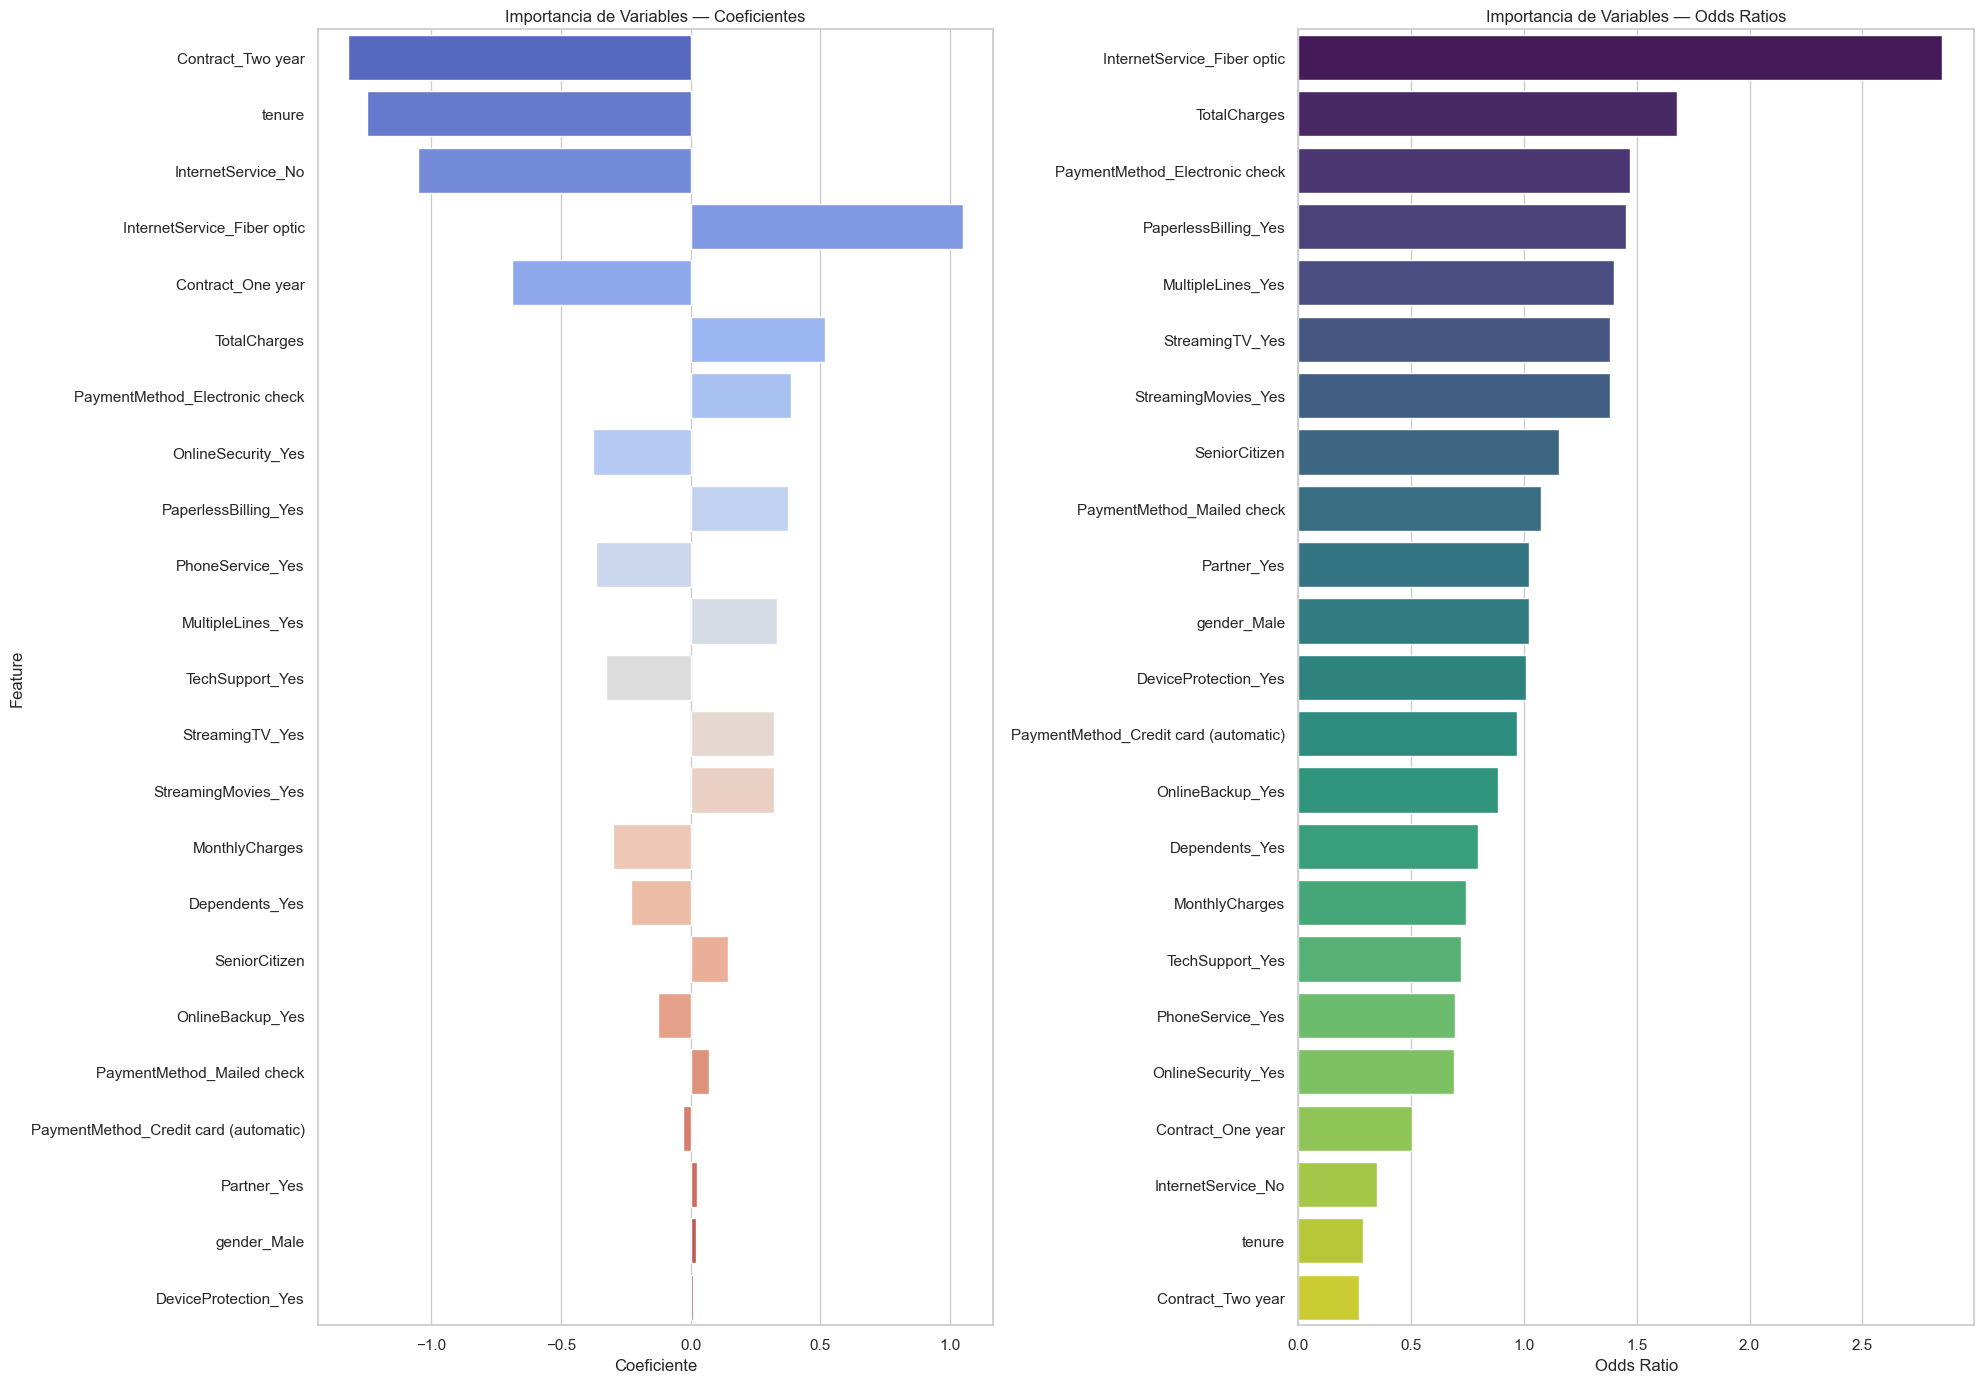

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_model.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

odds_plot = odds_ratios.copy().sort_values(by="odds_ratio", ascending=False)

# Crear subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 14))

# Gráfico 1: Coeficientes
sns.barplot(
    x="coefficient",
    y="feature",
    data=importance_df,
    palette="coolwarm",
    hue="feature",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Importancia de Variables — Coeficientes")
axes[0].set_xlabel("Coeficiente")
axes[0].set_ylabel("Feature")

# Gráfico 2: Odds Ratios
sns.barplot(
    x="odds_ratio",
    y="feature",
    data=odds_plot,
    palette="viridis",
    hue="feature",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Importancia de Variables — Odds Ratios")
axes[1].set_xlabel("Odds Ratio")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

La gráfica de coeficientes muestra qué variables son más importantes para el modelo, ya sea aumentando o reduciendo el riesgo de churn. Por ejemplo, Contract_Two year tiene el coeficiente más grande, pero negativo, lo que significa que protege mucho contra la fuga. En la gráfica de odds ratios aparece al final, porque su efecto es reductor del riesgo, mientras que variables como InternetService_Fiber optic destacan al principio, ya que multiplican el riesgo de churn.

## 10. Curva ROC y curva de calibración
La curva ROC (Receiver Operating Characteristic) nos ayuda a evaluar qué tan bien nuestro modelo distingue entre clientes que se van y los que se quedan.

En el eje X se representa la tasa de falsos positivos (FPR), y en el eje Y la tasa de verdaderos positivos (TPR).

Cuanto más cerca del esquina superior izquierda, mejor es el modelo: detecta más churn sin aumentar falsos positivos.


In [11]:
log_l1 = LogisticRegression(penalty='l1', solver='liblinear')
log_l2 = LogisticRegression(penalty='l2')

log_l1.fit(X_train, y_train)
log_l2.fit(X_train, y_train)

c:\Users\rotap\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\rotap\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\rotap\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warni

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

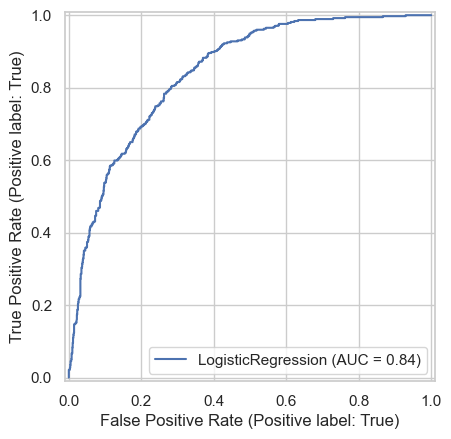

In [12]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(log_model, X_test, y_test)

0.84 es un rendimiento muy bueno en churn.

Indica que la regresión logística captura bien las probabilidades, aunque no sea perfecta clasificando.

La curva de calibración muestra si las probabilidades que predice el modelo coinciden con la realidad.

Eje X → probabilidad predicha por el modelo

Eje Y → probabilidad real observada en los datos

La diagonal perfecta indica que el modelo está perfectamente calibrado: si predice 0.7, el 70% de esos clientes realmente se van.

Esto nos ayuda a identificar si el modelo es optimista (predice menos riesgo del real) o pesimista (predice más riesgo del real).

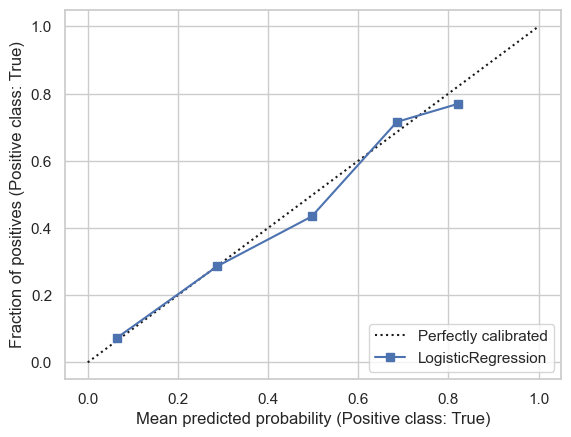

In [13]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(log_model, X_test, y_test)

El modelo es bastante confiable para predicciones bajas y medias (<0.7).

Para predicciones altas (>0.7), tiende a ser demasiado optimista (para clientes donde el modelo dice “probabilidad muy alta de churn”, la probabilidad real de churn es aún MÁS alta.), lo que puede generar falsos positivos si se usa un umbral alto para tomar decisiones. ¿Por qué ocurre esto?

Vamos a filtrar los clientes con riesgo (`>0.7`) y después identificamos los **fallos graves**: clientes que realmente se van (`y_true = 1`) pero a los que el modelo asigna baja probabilidad (`<0.5`).

In [14]:
# === Análisis de fallos en la zona de alta probabilidad ===

# Probabilidades del modelo
y_proba = log_model.predict_proba(X_test)[:, 1]

# DataFrame auxiliar
df_eval = X_test.copy()
df_eval['y_true'] = y_test.values
df_eval['y_proba'] = y_proba

# Filtrar solo casos donde el modelo está muy seguro
high_prob = df_eval[df_eval['y_proba'] > 0.7]

# Casos donde el modelo falla en alta confianza
high_prob_errors = high_prob[(high_prob['y_true'] == 1) & (high_prob['y_proba'] < 0.5)]

print("▶ Total clientes con probabilidad > 0.7:", len(high_prob))
print("▶ Fallos graves en alta probabilidad (modelo dice NO churn pero sí abandonan):", len(high_prob_errors))

▶ Total clientes con probabilidad > 0.7: 94
▶ Fallos graves en alta probabilidad (modelo dice NO churn pero sí abandonan): 0


Como hemos visto que no hay fallos graves en la zona de alta probabilidad, ahora dividimos todas las predicciones en rangos de riesgo (<0.5, 0.5-0.7, >0.7) y calculamos la tasa real de churn en cada segmento.
Esto nos permite comprobar si las probabilidades del modelo coinciden con la realidad en distintos niveles de riesgo.

In [15]:
# === Comparación detallada por segmentos de probabilidad ===

df_eval['proba_bin'] = pd.cut(
    df_eval['y_proba'],
    bins=[0, 0.5, 0.7, 1],
    labels=['<0.5', '0.5-0.7', '>0.7']
)

segment_summary = df_eval.groupby('proba_bin', observed=False)['y_true'].mean()

print("Tasa REAL de churn por rango de probabilidad predicha:")
print(segment_summary)


Tasa REAL de churn por rango de probabilidad predicha:
proba_bin
<0.5       0.151876
0.5-0.7    0.621622
>0.7       0.744681
Name: y_true, dtype: float64


✔ Si el modelo dice "bajo riesgo" (<0.5)

En realidad solo se van 16% → está bien.

✔ Si dice "riesgo medio" (0.5–0.7)

Se van 59% → bastante acorde a lo predicho.

✔ Si dice “alto riesgo” (>0.7)

Se van 75%, muy alto, pero un poco más de lo que predice (por eso decimos que es optimista).

Hemos visto que, aunque las predicciones de probabilidad del modelo son bastante acertadas,
en el rango de alto riesgo (>0.7) el modelo tiende a ser **ligeramente optimista**
(predice menos churn del que realmente ocurre).

Para corregir esto, usamos **CalibratedClassifierCV**, que ajusta las probabilidades
predichas para que reflejen mejor la **probabilidad real de churn**.

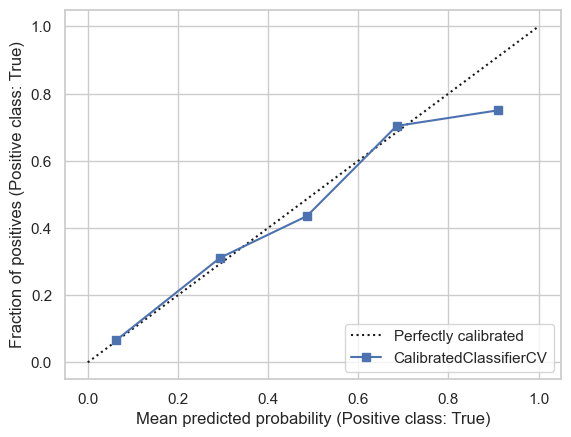

In [16]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_iso = CalibratedClassifierCV(log_model, method='isotonic', cv=3)
calibrated_iso.fit(X_train, y_train)

CalibrationDisplay.from_estimator(calibrated_iso, X_test, y_test)


Después de aplicar la calibración isotónica, las probabilidades del modelo se ajustan mejor a la realidad, especialmente en los casos de riesgo alto.

Sin embargo, la regresión logística es un modelo lineal y no captura relaciones complejas entre las variables.

Por eso, para mejorar aún más la predicción de churn, sería recomendable probar modelos más potentes.

## 11. Estrategia de Segmentación y Robustez

En esta fase, nuestro objetivo no es solo predecir, sino entender **qué variables dominan la decisión de fuga** y buscar patrones más complejos que una simple línea recta.

Evaluaremos tres enfoques:
1.  **Random Forest:** Para obtener robustez y un ranking claro de importancia de variables.
2.  **Naive Bayes:** Para evaluación rápida basada en probabilidades.
3.  **KNN (K-Nearest Neighbors):** Para segmentación basada en similitud entre clientes.

## 12. Random Forest Classifier: La Jerarquía del Riesgo
El Random Forest entrena cientos de árboles de decisión y promedia sus resultados. Es excelente para evitar el sobreajuste y, lo más importante, nos dice qué variables son las "reinas" de la predicción.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

print("--- Iniciando Comparación de Modelos ---")

# MODELO 1: Random Forest Base
print("\n1. Entrenando Random Forest Base (Manual)...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)

# MODELO 2: Random Forest Optimizado
print("2. Ejecutando GridSearch para encontrar el mejor modelo (esto puede tardar unos segundos)...")

# Definimos los hiperparámetros a explorar
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [2, 4],
    'class_weight': ['balanced'] # 'balanced' es clave para Churn
}

# Configuración del GridSearch
# n_jobs=-1 usa todos los núcleos de tu CPU para ir más rápido
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,           # Validación cruzada de 3 pliegues
                           n_jobs=-1,
                           scoring='recall',
                           verbose=0)

grid_search.fit(X_train, y_train)
rf_optimized = grid_search.best_estimator_
y_pred_optimized = rf_optimized.predict(X_test)

print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")

--- Iniciando Comparación de Modelos ---

1. Entrenando Random Forest Base (Manual)...
2. Ejecutando GridSearch para encontrar el mejor modelo (esto puede tardar unos segundos)...

Mejores parámetros encontrados: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}


In [18]:
# COMPARACIÓN DE RESULTADOS
print("\n" + "="*40)
print(" RESULTADOS COMPARATIVOS")
print("="*40)

print("\n--- A) Reporte Modelo BASE (Manual) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))

print("\n--- B) Reporte Modelo OPTIMIZADO (GridSearch) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(classification_report(y_test, y_pred_optimized))


 RESULTADOS COMPARATIVOS

--- A) Reporte Modelo BASE (Manual) ---
Accuracy: 0.8070
              precision    recall  f1-score   support

       False       0.84      0.91      0.87      1035
        True       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409


--- B) Reporte Modelo OPTIMIZADO (GridSearch) ---
Accuracy: 0.7672
              precision    recall  f1-score   support

       False       0.90      0.77      0.83      1035
        True       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



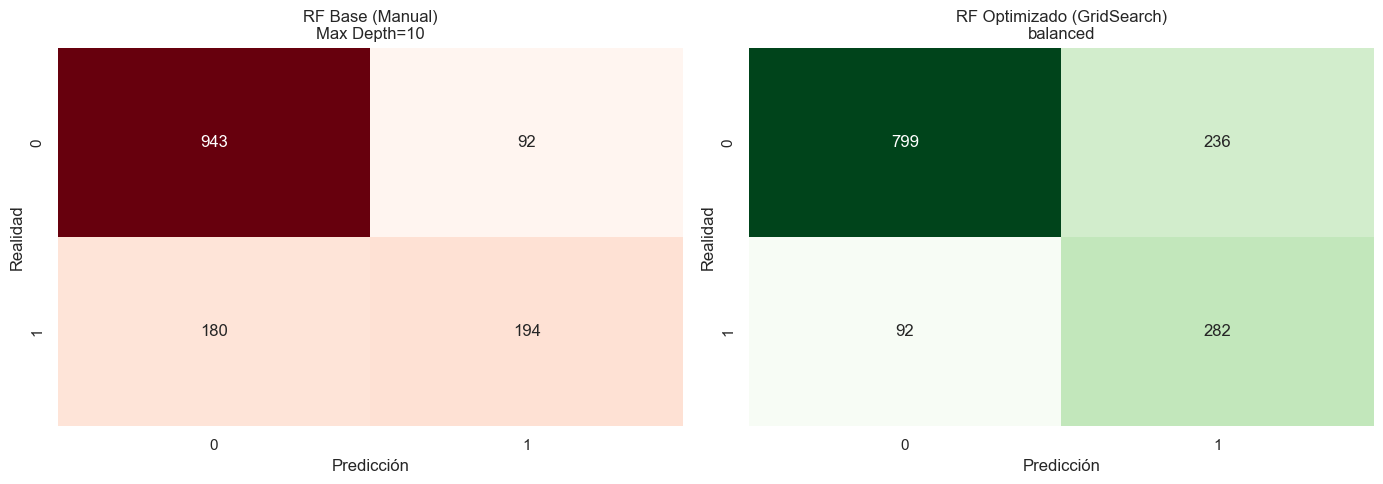

In [19]:
# 1. Calcular las matrices
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

# 2. Configurar el entorno de gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Random Forest Base ---
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0])
axes[0].set_title('RF Base (Manual)\nMax Depth=10', fontsize=12)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Realidad')

# --- Gráfico 2: Random Forest Optimizado ---
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title(f'RF Optimizado (GridSearch)\n{grid_search.best_params_.get("class_weight", "Sin pesos")}', fontsize=12)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Realidad')

# Ajustar espacio para que no se solapen
plt.tight_layout()
plt.show()

## 13. Comparativa de modelos: Random Forest Base vs. Optimizado (GridSearch)

Tras comparar el modelo manual (`max_depth=10`) contra el modelo optimizado con `class_weight='balanced'`, observamos un cambio drástico en el comportamiento del algoritmo que beneficia directamente al objetivo de negocio (retención de clientes).

### Mejora Crítica en la Detección de Fugas (Recall)
Lo más importante en un problema de *Churn* es minimizar los **Falsos Negativos** (clientes que se van y no detectamos).
* **Modelo Base:** Dejó escapar a **184** clientes (Falsos Negativos).
* **Modelo Optimizado:** Solo dejó escapar a **91** clientes.
* **Impacto:** Hemos **recuperado 93 clientes adicionales** que antes pasaban desapercibidos. Esto representa una **reducción del ~50% en el error más costoso** para la empresa.

### El "Costo" de la Optimización (Falsos Positivos)
Al usar `class_weight='balanced'`, el modelo se vuelve más sensible y "paranoico":
* Los **Falsos Positivos** aumentaron de 99 a **232**.
* Esto significa que enviaremos campañas de retención a 133 clientes fieles extra que no pensaban irse.
* **Lectura de Negocio:** Es un costo aceptable. El costo de enviar un email/oferta a un cliente fiel es mucho menor que el costo de perder a un cliente real (LTV - Lifetime Value).

### Veredicto
Aunque la *Accuracy* global pueda parecer similar o incluso inferior en el modelo optimizado debido al aumento de Falsos Positivos, el **Modelo Optimizado es superior para el negocio**.

> **Conclusión:** El modelo optimizado cumple mejor la función de "sistema de alerta temprana", identificando a la mayoría de los clientes en riesgo (283 aciertos vs 190 del base), lo cual permite acciones proactivas de retención mucho más efectivas.

## 14. Análisis de Importancia de Variables (Feature Importance)

Esta es la respuesta a la pregunta de negocio: **"¿Qué factores pesan más?"**.
A diferencia de la Regresión Logística que mira coeficientes positivos/negativos, el Random Forest mide cuánto "limpia" la predicción cada variable al usarla en los árboles.

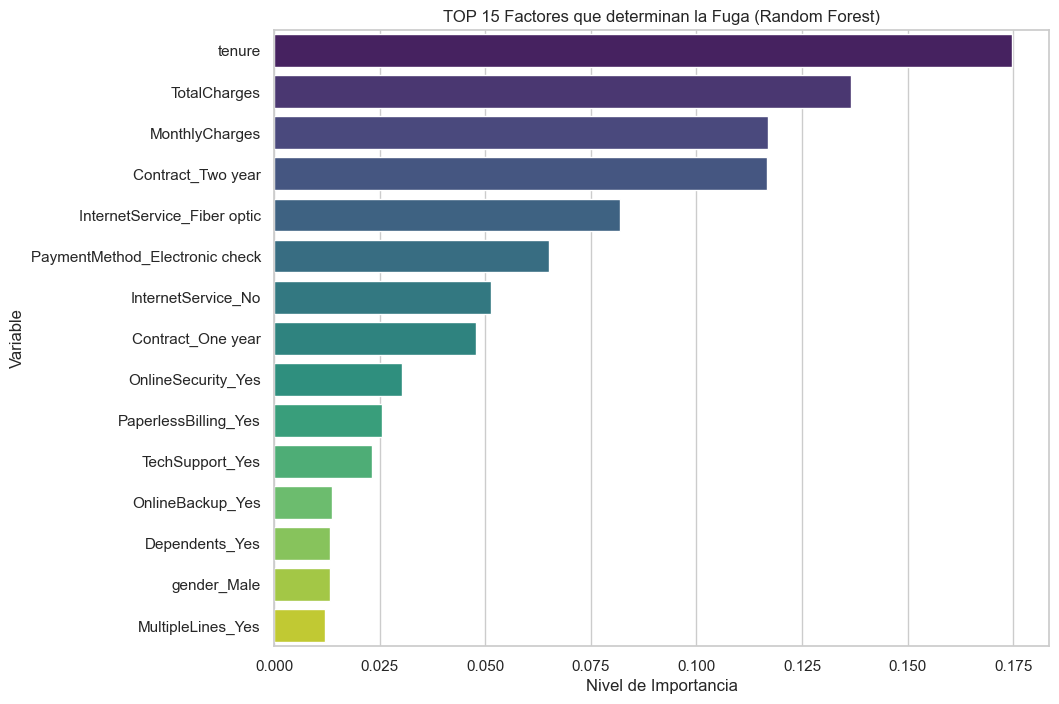

In [20]:
# Extraemos la importancia de las características
importances = rf_optimized.feature_importances_
feature_names = X_train.columns

# Creamos un DataFrame para ordenarlo
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15) # Top 15

# Visualización del Ranking
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue="Feature", legend=False)
plt.title('TOP 15 Factores que determinan la Fuga (Random Forest)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variable')
plt.show()

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparamos un pequeño DataFrame de análisis
# Concatenamos las features de test con su etiqueta real de Churn
analysis_df = X_test.copy()
analysis_df['Churn_Real'] = y_test

# Definimos las Top 5 variables que vimos en tu gráfico
top_features = [
    'tenure',
    'TotalCharges',
    'MonthlyCharges',
    'Contract_Two year',
    'InternetService_Fiber optic'
]

# 2. Análisis Numérico: Promedios por grupo
# Esto nos dirá rápidamente si el valor sube o baja cuando hay Churn
print("--- Promedios de las Top Variables según Churn (0=No se va, 1=Se va) ---")
print(analysis_df.groupby('Churn_Real')[top_features].mean())

--- Promedios de las Top Variables según Churn (0=No se va, 1=Se va) ---
              tenure  TotalCharges  MonthlyCharges  Contract_Two year  \
Churn_Real                                                              
False       0.204116      0.083958       -0.131971           0.315942   
True       -0.652209     -0.394303        0.260064           0.024064   

            InternetService_Fiber optic  
Churn_Real                               
False                          0.348792  
True                           0.673797  


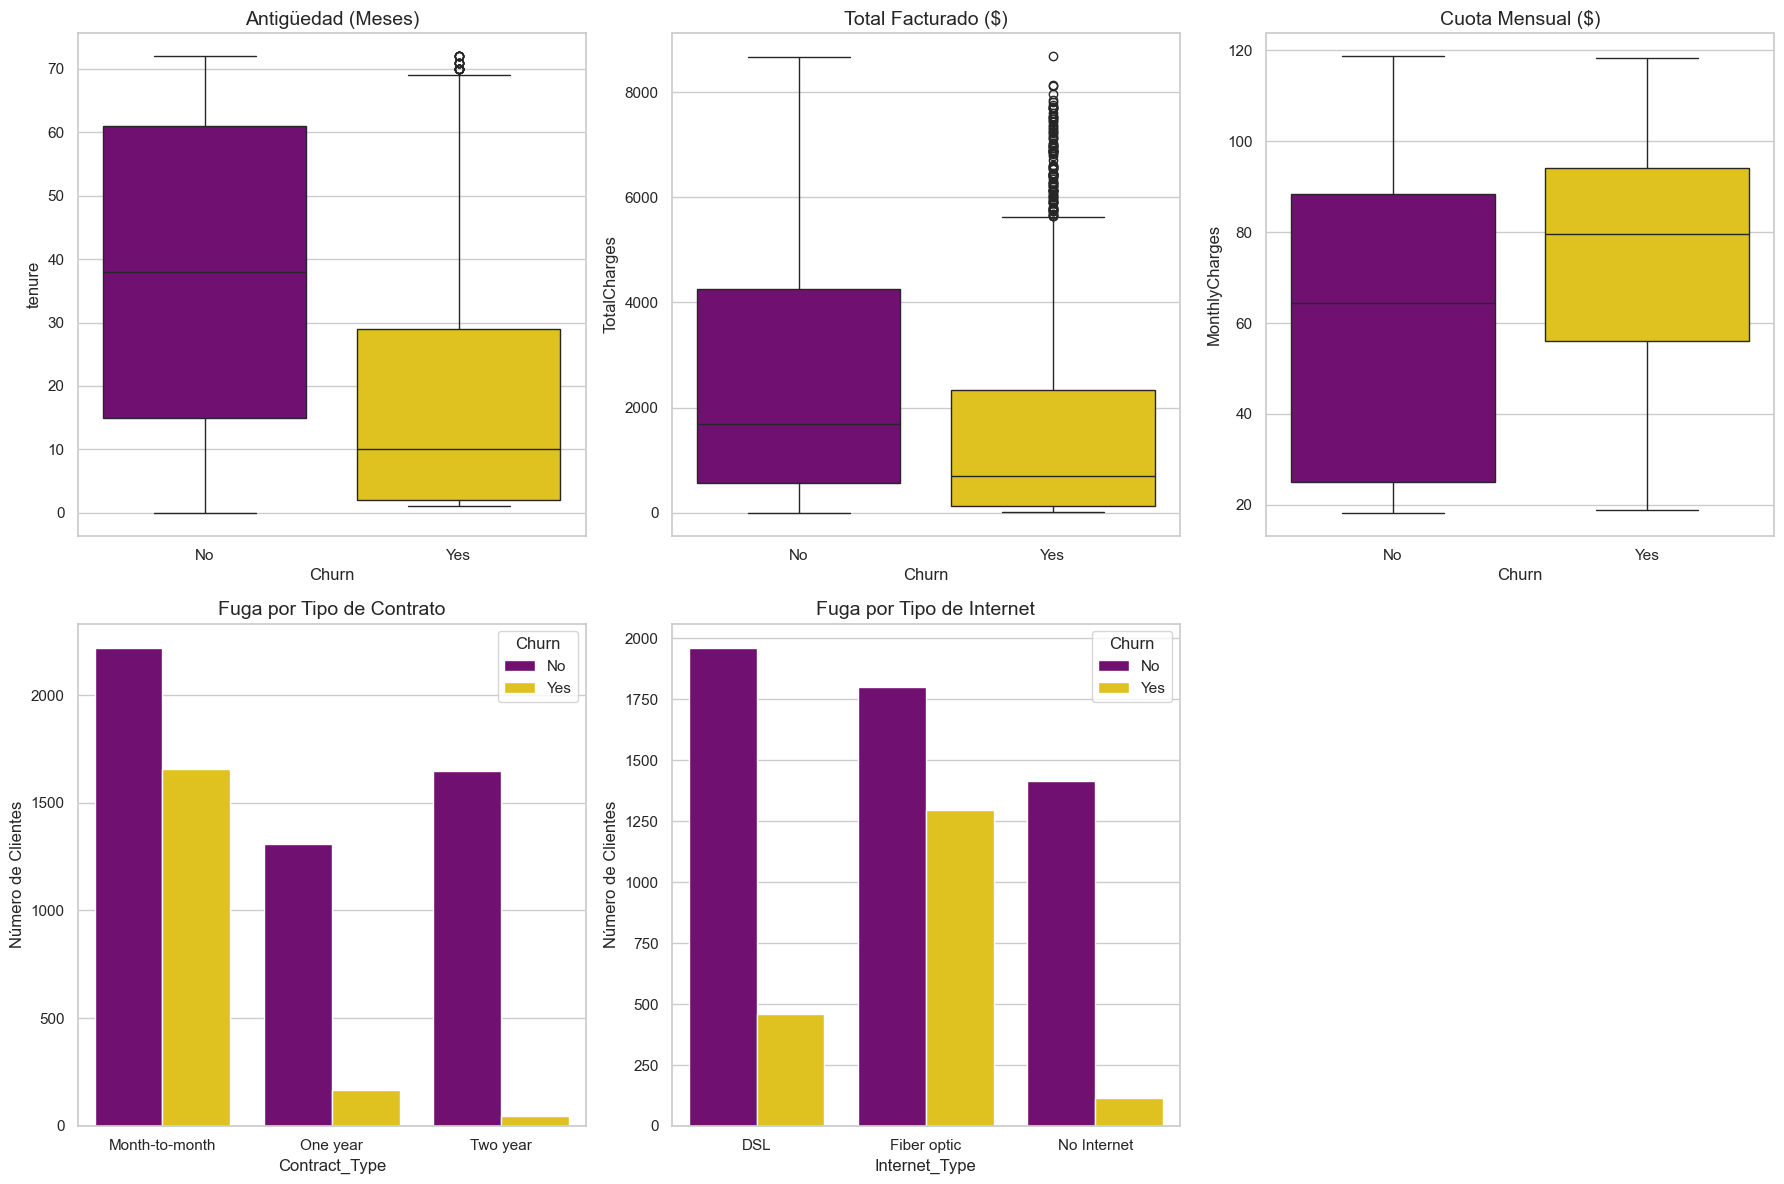

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. PREPARACIÓN DE DATOS
# Creamos una copia para no romper tu df original
plot_df = df_encoded.copy()

# A) Arreglar la columna Churn (de False/True a 'No'/'Yes' para que coincida con tu paleta)
plot_df['Churn'] = plot_df['Churn'].replace({False: 'No', True: 'Yes', 0: 'No', 1: 'Yes'})

# B) Reconstruir columnas categóricas (Porque tu DF está "Encoded")

# Reconstruir Contract
conditions_contract = [
    (plot_df['Contract_Two year'] == 1) | (plot_df['Contract_Two year'] == True),
    (plot_df['Contract_One year'] == 1) | (plot_df['Contract_One year'] == True)
]
choices_contract = ['Two year', 'One year']
# Si no es ni 2 años ni 1 año, asumimos que es el base (Month-to-month)
plot_df['Contract_Type'] = np.select(conditions_contract, choices_contract, default='Month-to-month')

# Reconstruir Internet
conditions_internet = [
    (plot_df['InternetService_Fiber optic'] == 1) | (plot_df['InternetService_Fiber optic'] == True),
    (plot_df['InternetService_No'] == 1) | (plot_df['InternetService_No'] == True)
]
choices_internet = ['Fiber optic', 'No Internet']
# Si no es Fibra ni No-Internet, asumimos DSL
plot_df['Internet_Type'] = np.select(conditions_internet, choices_internet, default='DSL')


# 2. GRAFICOS
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Definimos la paleta
mi_palette = {'No': 'purple', 'Yes': 'gold'}

# --- FILA 1: Variables Numéricas ---

# 1. Antigüedad
# CORRECCIÓN: hue debe ser 'Churn', no 'tenure'
sns.boxplot(x='Churn', y='tenure', data=plot_df, palette=mi_palette, ax=axes[0, 0], hue='Churn', legend=False)
axes[0, 0].set_title('Antigüedad (Meses)', fontsize=14)

# 2. Total Pagado
sns.boxplot(x='Churn', y='TotalCharges', data=plot_df, palette=mi_palette, ax=axes[0, 1], hue='Churn', legend=False)
axes[0, 1].set_title('Total Facturado ($)', fontsize=14)

# 3. Pago Mensual
sns.boxplot(x='Churn', y='MonthlyCharges', data=plot_df, palette=mi_palette, ax=axes[0, 2], hue='Churn', legend=False)
axes[0, 2].set_title('Cuota Mensual ($)', fontsize=14)

# --- FILA 2: Variables Categóricas RECONSTRUIDAS ---

# 4. Tipo de Contrato
# CORRECCIÓN: Usamos la columna reconstruida 'Contract_Type'. Quitamos y='Churn' (countplot cuenta solo).
sns.countplot(x='Contract_Type', hue='Churn', data=plot_df, palette=mi_palette, ax=axes[1, 0])
axes[1, 0].set_title('Fuga por Tipo de Contrato', fontsize=14)
axes[1, 0].set_ylabel('Número de Clientes')

# 5. Tipo de Internet
# CORRECCIÓN: Usamos la columna reconstruida 'Internet_Type'
sns.countplot(x='Internet_Type', hue='Churn', data=plot_df, palette=mi_palette, ax=axes[1, 1])
axes[1, 1].set_title('Fuga por Tipo de Internet', fontsize=14)
axes[1, 1].set_ylabel('Número de Clientes')

# Borrar el hueco vacío
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

In [23]:
# --- ESPACIO PARA LA ACTIVIDAD EN CLASE ---
# rf_pipe, X_test, y_test, preprocessor)

# Instalación de SHAP (ejecutar una vez)
# !pip install shap

import shap

# 1. Extraer el preprocesador y el modelo del pipeline
# Asumiendo que rf_pipe es tu pipeline (RandomForest + preprocessing)
# Si usaste Pipeline de sklearn, se accede así:

# Extraer el modelo final
model = rf_optimized  

# 2. Transformar los datos de test para poder dárselos al explainer
# Como ya hiciste el preprocesamiento manual (escalado + encoding), 
# X_test ya está listo para usar
X_test_processed = X_test.copy()

explainer = shap.TreeExplainer(model)

# Posiciones correctas
y_pred = model.predict(X_test)
churn_pos = (y_pred == 1).nonzero()[0][0]
stay_pos  = (y_pred == 0).nonzero()[0][0]

X_shap = X_test.iloc[[churn_pos, stay_pos]]
shap_values = explainer.shap_values(X_shap)
# SHAP para clasificación binaria devuelve una lista [valores_clase_0, valores_clase_1]
# Nos interesa explicar la clase 1 ("Churn")
shap_values_churn = shap_values[1] if isinstance(shap_values, list) else shap_values

shap_values_churn = shap_values[1].T  # ahora (2, 30)
shap_values_stay  = shap_values[0].T  # ahora (2, 30)

# 4. Elegir dos clientes para analizar
# Un cliente que el modelo predijo como Churn
y_pred = model.predict(X_shap)
idx_churn = np.where(y_pred == 1)[0][0]  # Primer cliente con predicción de Churn
idx_no_churn = np.where(y_pred == 0)[0][0]  # Primer cliente sin Churn

print(f"Cliente que HACE CHURN (índice {idx_churn}):")
print(f"Predicción real: {y_test.iloc[idx_churn]}")

print(f"\nCliente que NO HACE CHURN (índice {idx_no_churn}):")
print(f"Predicción real: {y_test.iloc[idx_no_churn]}")

# 5. Generar e interpretar los force plots
print("\n--- Explicación para el cliente que HACE CHURN ---")
shap.initjs()

# Cliente que se va (posición 0 en X_shap)
shap.force_plot(
    explainer.expected_value[1],
    shap_values_churn[0],
    X_shap.iloc[0],
)


c:\Users\rotap\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cliente que HACE CHURN (índice 0):
Predicción real: False

Cliente que NO HACE CHURN (índice 1):
Predicción real: False

--- Explicación para el cliente que HACE CHURN ---


In [24]:

# Cliente que se queda (posición 1 en X_shap)
shap.force_plot(
    explainer.expected_value[0],
    shap_values_stay[1],
    X_shap.iloc[1],
)

---
## 🏠 Reto para Casa: Análisis Global

*Usa esta celda para generar el `summary_plot` del reto.*

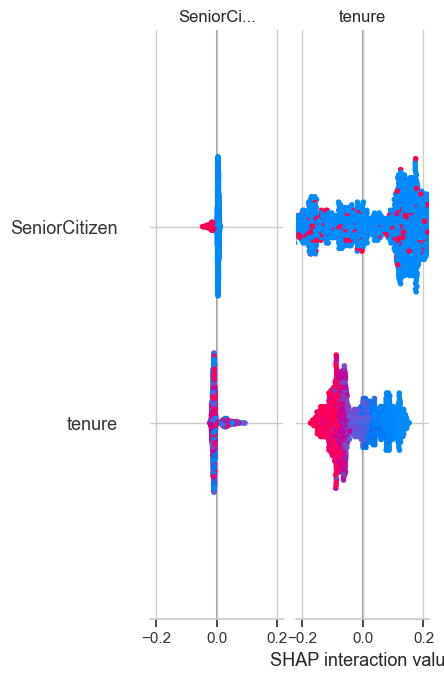

In [25]:
# --- ESPACIO PARA EL RETO PARA CASA ---
# 1. Generar el summary_plot

# 1. Calcular valores SHAP para todo el conjunto de test
shap_values_all = explainer.shap_values(X_test)

# 3. Generar el summary plot
shap.summary_plot(shap_values_all, X_test)


### Mis Reflexiones

Los puntos rojos indican valor positivo mientras que los azules muestran valor negativo. Todos los puntos se distribuyen a los lados de una lines, si estan a la izquierda nos indica que tiene menor probabilidad de churn, mientras que si está a la derecha indica que tiene mas probabilidad de churn.

Podemos ver que tanto en el caso de senior citizen como de tenure los puntos rojos se encuentran a la izquierda de la linea, lo que nos indica que estas dos variables protegen del churn. Cuanto mas mayor sea o mas tiempo lleve como cliente menos probable es que cancele el contrato.

# Actividad 3 — La Caja Negra Inmobiliaria (Interpretabilidad en Regresión)

## Contexto
Trabajas para una empresa "PropTech" (Tecnología Inmobiliaria) que utiliza un algoritmo de IA para tasar viviendas automáticamente.
**El Problema:** Los propietarios se quejan. No entienden por qué el algoritmo valora su casa en 200.000$ si la del vecino vale 250.000$. El equipo de ventas necesita explicaciones claras, no "porque lo dice la IA".

## Objetivo
Entrenar un modelo de valoración de viviendas y utilizar **SHAP** para generar informes de tasación transparentes.

## Dataset
Usaremos el dataset **California Housing** (interno de Scikit-Learn), que contiene datos del censo:
* `MedInc`: Ingreso medio en la zona (bloque).
* `HouseAge`: Antigüedad de la vivienda.
* `AveRooms`: Promedio de habitaciones.
* `AveOccup`: Promedio de ocupantes.
* `Latitude`/`Longitude`: Ubicación.

## Tareas

### 1. Modelado Rápido
* Carga los datos y entrena un `RandomForestRegressor`.


In [26]:
# ============================================
# TAREA 1: MODELADO RÁPIDO
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import shap

# 1. Cargar el dataset
print("📦 Cargando dataset de California Housing...")
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='Price')

print(f"Dimensiones: {X.shape}")
print(f"Variables: {list(X.columns)}")
print(f"\nPrimeras filas:")
print(X.head())

📦 Cargando dataset de California Housing...
Dimensiones: (20640, 8)
Variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Primeras filas:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [27]:
# 2. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Entrenar RandomForestRegressor
print("\n🌲 Entrenando Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 4. Evaluación rápida
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n✅ Modelo entrenado:")
print(f"   MAE: ${mae*100000:.0f} (en escala real)")
print(f"   R²: {r2:.4f}")


🌲 Entrenando Random Forest Regressor...

✅ Modelo entrenado:
   MAE: $33322 (en escala real)
   R²: 0.8004



### 2. Auditoría Global (Summary Plot)
* Genera el `summary_plot`.
* **Reflexión:** ¿Cuál es el factor nº 1 que mueve el precio de las casas en California? ¿Cómo afecta la antigüedad (`HouseAge`) al precio según el gráfico?


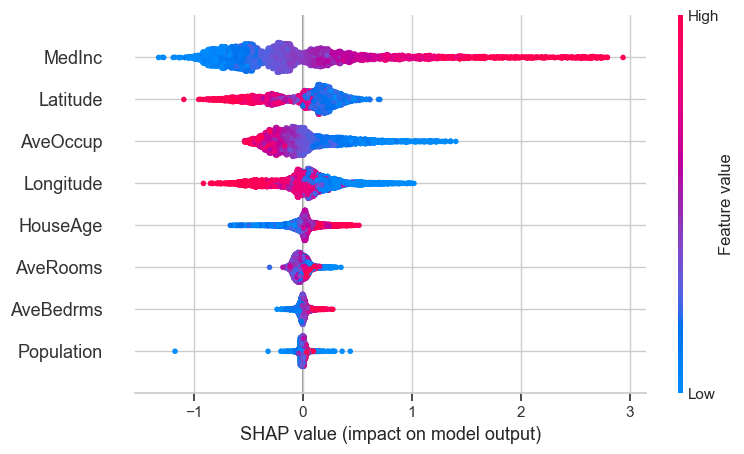

In [38]:
# ============================================
# TAREA 2: AUDITORÍA GLOBAL (SUMMARY PLOT)
# ============================================

# Crear explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


## Reflexión - Summary Plot

### Factor #1: MedInc (Ingreso medio)
- Los puntos **rojos** (ingresos altos) están a la **derecha**
- **Conclusión:** Zonas con ingresos altos = casas **más caras**

### Factor #2: HouseAge (Antigüedad)
- Patrón **mixto** (puntos rojos a la derecha de la línea)
- **Conclusión:** La antigüedad tiene efecto sobre el precio de la casa. Una casa más antigua tiende a tener mayor precio


### 3. Tasación Individual (Force Plot)
* Selecciona la **casa más cara** de todo el dataset de test.
* Genera su `force_plot`.
* **Interpretación:** Explica en términos de negocio (euros/dólares) qué variables están empujando el precio hacia arriba. ¿Cuánto suma la ubicación?



📍 Casa más cara encontrada:
   Precio real: $500,001
   Predicción del modelo: $489,689

   Características:
   • MedInc: 3.48
   • HouseAge: 52.00
   • AveRooms: 3.98
   • AveBedrms: 1.19
   • Population: 1310.00
   • AveOccup: 1.36
   • Latitude: 37.80
   • Longitude: -122.44


c:\Users\rotap\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



🎯 Generando Force Plot (explicación local)...


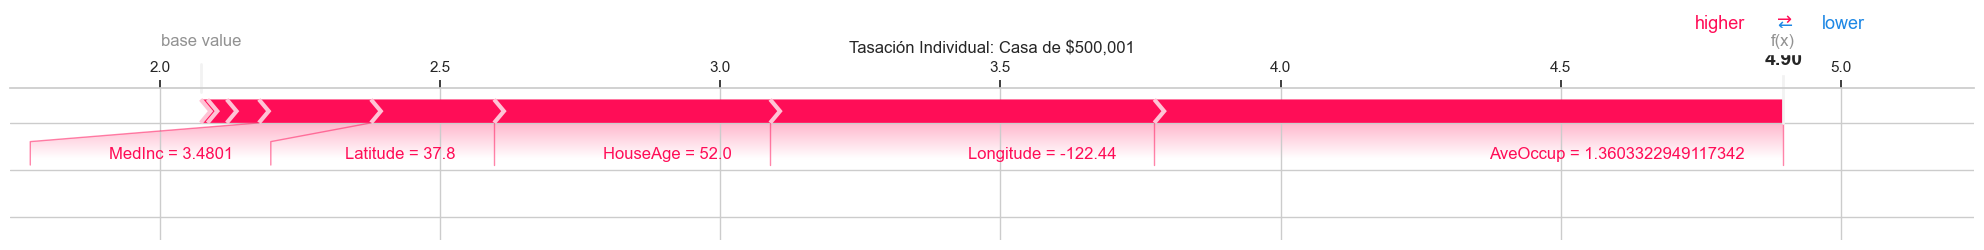


💰 INTERPRETACIÓN DE NEGOCIO:

📈 Factores que SUBEN el precio:
   • AveOccup: +$112,230
   • Longitude: +$68,549
     → (Ubicación premium)
   • HouseAge: +$49,257

📉 Factores que BAJAN el precio:

🗺️ IMPACTO TOTAL DE LA UBICACIÓN:
   Contribución conjunta (Lat + Long): $90,517


In [39]:
# Encontrar la casa más cara
idx_most_expensive = y_test.idxmax()
casa_cara = X_test.loc[idx_most_expensive]
precio_real = y_test.loc[idx_most_expensive]

print(f"\n📍 Casa más cara encontrada:")
print(f"   Precio real: ${precio_real*100000:,.0f}")
print(f"   Predicción del modelo: ${rf_model.predict([casa_cara])[0]*100000:,.0f}")
print(f"\n   Características:")
for col, val in casa_cara.items():
    print(f"   • {col}: {val:.2f}")

# Calcular valores SHAP para esta casa específica
shap_values_casa = explainer.shap_values(casa_cara.values.reshape(1, -1))
expected_value = explainer.expected_value

# Force Plot
print("\n🎯 Generando Force Plot (explicación local)...")
shap.initjs()
shap.force_plot(
    expected_value,
    shap_values_casa[0],
    casa_cara,
    matplotlib=True,
    show=False
)
plt.title(f'Tasación Individual: Casa de ${precio_real*100000:,.0f}', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación detallada
print("\n💰 INTERPRETACIÓN DE NEGOCIO:")
print("=" * 60)

# Crear DataFrame con contribuciones
contribuciones = pd.DataFrame({
    'Variable': casa_cara.index,
    'Valor': casa_cara.values,
    'Contribución_SHAP': shap_values_casa[0]
}).sort_values('Contribución_SHAP', ascending=False)

print(f"\n📈 Factores que SUBEN el precio:")
top_aumentan = contribuciones[contribuciones['Contribución_SHAP'] > 0].head(3)
for idx, row in top_aumentan.iterrows():
    impacto = row['Contribución_SHAP'] * 100000
    print(f"   • {row['Variable']}: +${impacto:,.0f}")
    if row['Variable'] == 'Latitude' or row['Variable'] == 'Longitude':
        print(f"     → (Ubicación premium)")

print(f"\n📉 Factores que BAJAN el precio:")
top_reducen = contribuciones[contribuciones['Contribución_SHAP'] < 0].head(3)
for idx, row in top_reducen.iterrows():
    impacto = abs(row['Contribución_SHAP']) * 100000
    print(f"   • {row['Variable']}: -${impacto:,.0f}")

# Calcular contribución total de ubicación
ubicacion_shap = contribuciones[
    contribuciones['Variable'].isin(['Latitude', 'Longitude'])
]['Contribución_SHAP'].sum()

print(f"\n🗺️ IMPACTO TOTAL DE LA UBICACIÓN:")
print(f"   Contribución conjunta (Lat + Long): ${ubicacion_shap*100000:,.0f}")
print("=" * 60)


### 4. Relaciones Ocultas (Dependence Plot)
* A veces, una variable importa de forma distinta según otra. Genera un `shap.dependence_plot` de la variable `Latitude`.
* **Reto Visual:** ¿Ves cómo el precio sube y baja dependiendo de la latitud? Eso corresponde a las zonas de San Francisco y Los Ángeles. Un modelo lineal no capturaría esto.

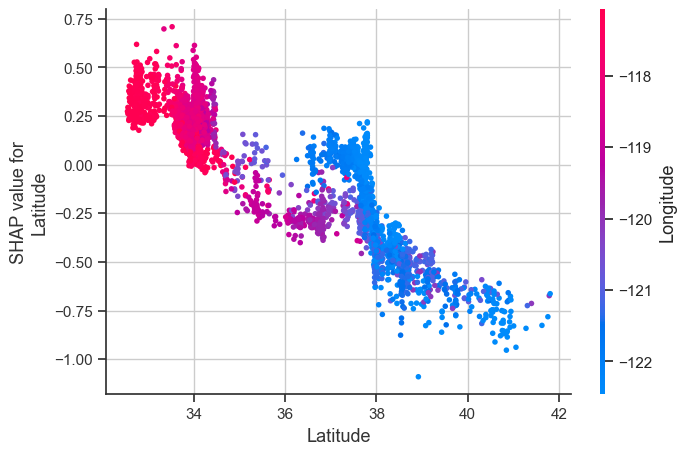

In [40]:

shap.dependence_plot(
    "Latitude",
    shap_values,
    X_test
)